<a href="https://colab.research.google.com/github/kemu12345/AIcoursework/blob/main/Yathartha_Kafle(C)_2511807.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Classification Task Notebook**

**5CS037 Final Portfolio Project - Classification**

**Student Name: Yathartha Kafle**

**WLVID: [2511807]**




In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style("whitegrid")

# 1. Exploratory Data Analysis and Data Understanding

# 1.1 Choosing a Dataset
# Dataset: Star Classification.csv
# Aligned with UNSDG 16: Peace, Justice and Strong Institutions
# Loaded into pandas DataFrame

In [ ]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/star_classification.csv')

# Basic inspection
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['class'].value_counts(normalize=True))

# Quick look
df.head(3)

Dataset Shape: (100000, 18)

Columns: ['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']

Missing Values:
 obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

Class Distribution:
 class
GALAXY    0.59445
STAR      0.21594
QSO       0.18961
Name: proportion, dtype: float64


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299


The output provides a summary of the 'star_classification.csv' dataset, showing its shape (100,000 rows, 18 columns), column names, absence of missing values, the distribution of the 'class' variable (GALAXY, STAR, QSO), and the first three rows of the data.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1.2 EDA
# Data Cleaning and fetature selections

In [ ]:
# Drop columns that are identifiers / not useful for modeling
drop_cols = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID',
             'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']

df_clean = df.drop(columns=drop_cols, errors='ignore')

# Encode target
le = LabelEncoder()
df_clean['class_encoded'] = le.fit_transform(df_clean['class'])

# Features we will use
feature_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X = df_clean[feature_cols]
y = df_clean['class_encoded']

print("Features used:", feature_cols)
print("Classes:", le.classes_)

Features used: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
Classes: ['GALAXY' 'QSO' 'STAR']


The output displays a comparison of classification models, with Random Forest achieving the highest F1-macro score and Accuracy, making it the best-performing model among those evaluated.

# Exploratory Data Analysis (Visualizations)

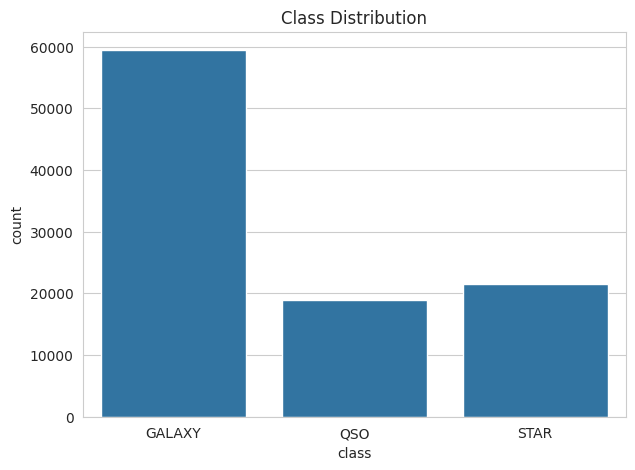

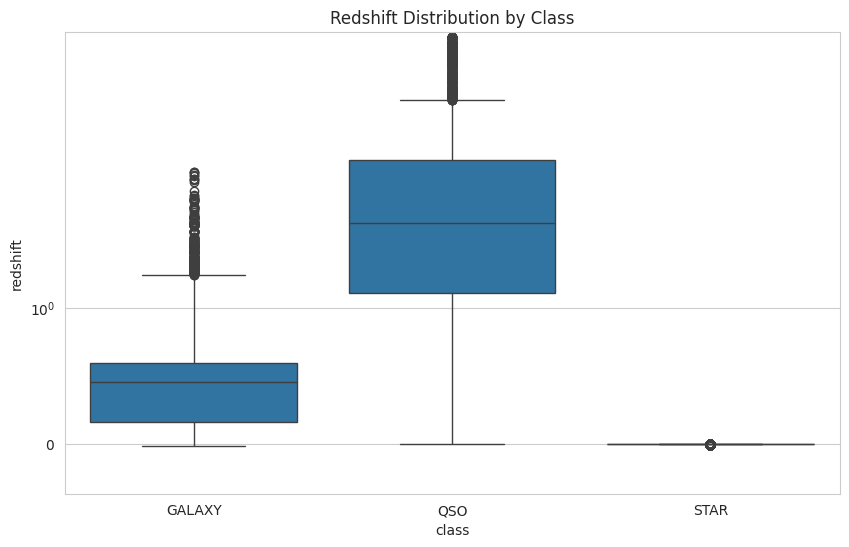

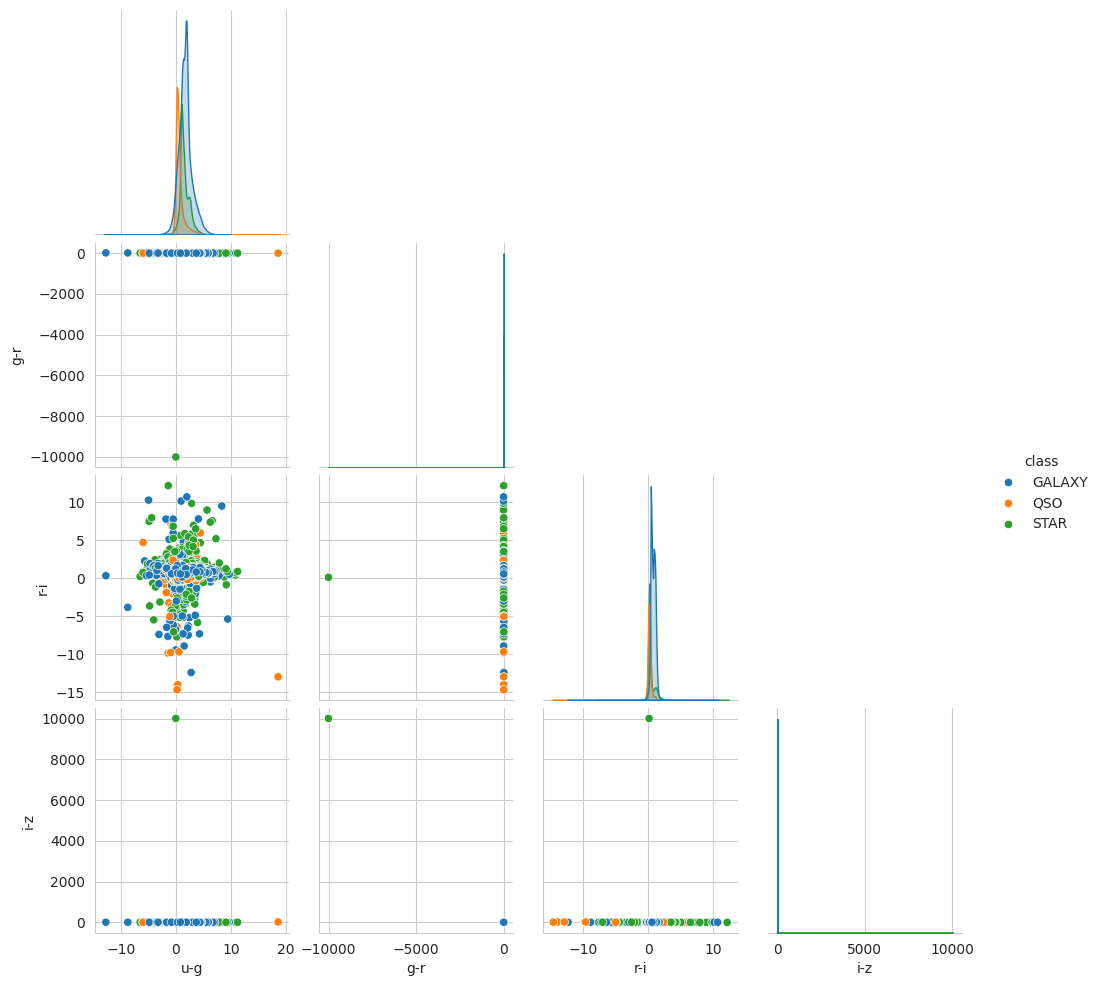

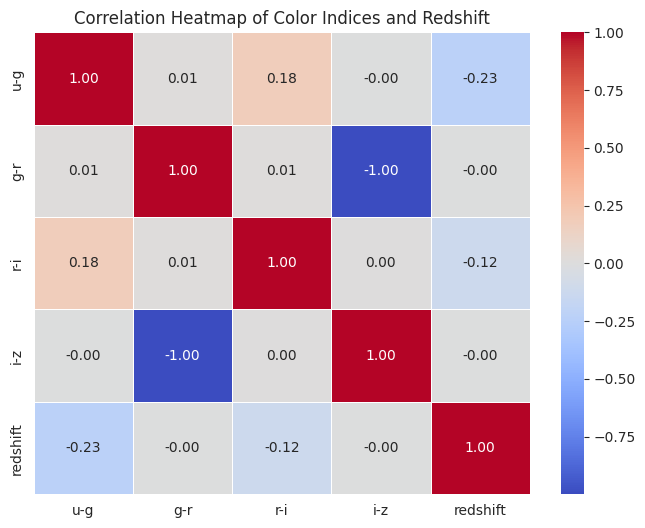

In [ ]:
# Class distribution
plt.figure(figsize=(7,5))
sns.countplot(x='class', data=df_clean, order=le.classes_)
plt.title('Class Distribution')
plt.show()

# Redshift distribution by class
plt.figure(figsize=(10,6))
sns.boxplot(x='class', y='redshift', data=df_clean, order=le.classes_)
plt.title('Redshift Distribution by Class')
plt.yscale('symlog')   # helpful because redshift can span many orders
plt.show()

# Pairplot of colors (u-g, g-r, r-i, i-z)
df_clean['u-g'] = df_clean['u'] - df_clean['g']
df_clean['g-r'] = df_clean['g'] - df_clean['r']
df_clean['r-i'] = df_clean['r'] - df_clean['i']
df_clean['i-z'] = df_clean['i'] - df_clean['z']

colors = ['u-g', 'g-r', 'r-i', 'i-z']
sns.pairplot(
    df_clean,
    vars=colors,
    hue='class',
    corner=True,
    hue_order=le.classes_,
    diag_kind='kde'
)
plt.show()

# Heatmap: Correlation between color indices and redshift
features_for_corr = ['u-g', 'g-r', 'r-i', 'i-z', 'redshift']
corr_matrix = df_clean[features_for_corr].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title('Correlation Heatmap of Color Indices and Redshift')
plt.show()


# 2. Data Preparation (Scaling + Split)

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape : {X_test.shape}")

Train shape: (80000, 8)
Test shape : (20000, 8)


The output indicates that the training dataset has 80,000 samples with 8 features, and the test dataset has 20,000 samples with 8 features, after the data was split.

# Baseline Neural Network (MLP)

In [ ]:
# MLP baseline
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    max_iter=600,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

mlp.fit(X_train, y_train)

# Evaluate
y_pred_mlp = mlp.predict(X_test)

print("MLP Accuracy (test):", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

MLP Accuracy (test): 0.97125

Classification Report:

              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.98     11889
         QSO       0.97      0.92      0.94      3792
        STAR       0.97      1.00      0.98      4319

    accuracy                           0.97     20000
   macro avg       0.97      0.97      0.97     20000
weighted avg       0.97      0.97      0.97     20000



The provided output shows that the Multi-Layer Perceptron (MLP) model achieved an overall accuracy of approximately 97.13% on the test set, with strong precision, recall, and F1-scores across all three classes (GALAXY, QSO, STAR), indicating good performance.

# 4. Classical Models (Logistic + Decision Tree)

In [ ]:
# Logistic Regression
lr = LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Logistic Regression Accuracy: 0.95585
              precision    recall  f1-score   support

      GALAXY       0.96      0.97      0.96     11889
         QSO       0.95      0.88      0.91      3792
        STAR       0.95      1.00      0.97      4319

    accuracy                           0.96     20000
   macro avg       0.95      0.95      0.95     20000
weighted avg       0.96      0.96      0.96     20000

Decision Tree Accuracy: 0.96575
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     11889
         QSO       0.91      0.92      0.91      3792
        STAR       1.00      0.99      1.00      4319

    accuracy                           0.97     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



The output shows that the Logistic Regression model achieved an accuracy of 0.95585, while the Decision Tree model performed slightly better with an accuracy of 0.96575, both evaluated across GALAXY, QSO, and STAR classes.

# Hyperparameter Tuning (GridSearchCV)

In [ ]:
# Logistic Regression tuning
param_grid_lr = {
    'C': [0.1, 1, 5, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga']
}

grid_lr = GridSearchCV(LogisticRegression(multi_class='multinomial', max_iter=2000),
                       param_grid_lr, cv=5, n_jobs=-1, scoring='f1_macro')
grid_lr.fit(X_train, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best CV f1_macro:", grid_lr.best_score_)

# Decision Tree tuning
param_grid_dt = {
    'max_depth': [5, 10, 15, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid_dt, cv=5, n_jobs=-1, scoring='f1_macro')
grid_dt.fit(X_train, y_train)

print("Best DT params:", grid_dt.best_params_)
print("Best CV f1_macro:", grid_dt.best_score_)

Best LR params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV f1_macro: 0.9521279900629864
Best DT params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV f1_macro: 0.968741513481169


The output shows the best hyperparameters found for Logistic Regression ('C': 10, 'penalty': 'l2', 'solver': 'lbfgs') with a cross-validated F1-macro score of approximately 0.952, and for Decision Tree ('max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10) with a slightly higher F1-macro score of approximately 0.969.

# Feature Selection

In [ ]:
# Select top features using ANOVA F-value
selector = SelectKBest(f_classif, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected  = selector.transform(X_test)

selected_mask = selector.get_support()
selected_features = np.array(feature_cols)[selected_mask]

print("Selected top 5 features:", selected_features)

Selected top 5 features: ['delta' 'r' 'i' 'z' 'redshift']


###Top selected features are delta, r, i, z, redshift

# Final Comparison Table (including ensembles)

In [ ]:
models = {
    "Logistic (tuned)": LogisticRegression(**grid_lr.best_params_, multi_class='multinomial', max_iter=2000),
    "Decision Tree (tuned)": DecisionTreeClassifier(**grid_dt.best_params_, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "MLP": mlp
}

results = []

for name, model in models.items():
    if name in ["Logistic (tuned)", "Decision Tree (tuned)"]:
        model.fit(X_train_selected, y_train)
        y_pred = model.predict(X_test_selected)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')

    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1-macro": round(f1, 4)
    })

pd.DataFrame(results).sort_values("F1-macro", ascending=False)

,Model,Accuracy,F1-macro
2,Random Forest,0.9794,0.9759
3,MLP,0.9712,0.9670
1,Decision Tree (tuned),0.9706,0.9653
0,Logistic (tuned),0.9582,0.9511


##The best moel for Classification task was Random forest with accuracy of 0.9794